In [1]:
from pathlib import Path

from PIL import Image

poly_data_path = Path("/home/ashah/data-2025-04-21-not-processed")

image_file = list(poly_data_path.glob("*.npz"))

image_file[15] 

PosixPath('/home/ashah/data-2025-04-21-not-processed/P38_img-00002-00083_left_healthy_20.npz')

In [2]:
import matplotlib.pyplot as plt

import numpy as np

In [3]:
sample_image = np.load(image_file[15])
sample_image

NpzFile '/home/ashah/data-2025-04-21-not-processed/P38_img-00002-00083_left_healthy_20.npz' with keys: arr_0

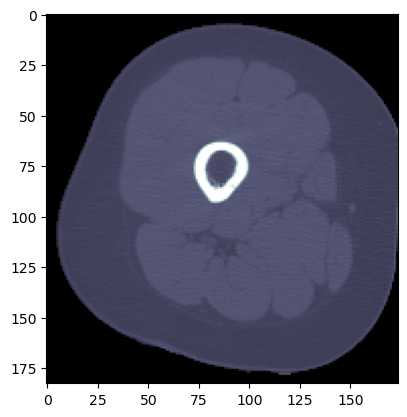

In [4]:
import matplotlib.pyplot as plt

plt.imshow(sample_image["arr_0"], cmap= "bone")

In [5]:
import os
import shutil
import tempfile
import matplotlib.pyplot as plt
import PIL
import torch
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from sklearn.metrics import classification_report

from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
)
from monai.utils import set_determinism

print_config()

2025-08-04 20:59:18.725348: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-04 20:59:18.738573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754333958.754264   72277 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754333958.759026   72277 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754333958.770752   72277 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

MONAI version: 1.4.0
Numpy version: 1.26.4
Pytorch version: 2.7.1+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: /home/<username>/.local/lib/python3.12/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.11.4
Pillow version: 10.2.0
Tensorboard version: 2.19.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.22.1+cu126
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.8
pandas version: 2.3.0
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
c

In [6]:
import os
import numpy as np

data_dir = "/home/ashah/data-2025-04-21-not-processed"
npz_files = [f for f in os.listdir(data_dir) if f.endswith('.npz')]

all_data = []  # or {} if you prefer dictionary keyed by filename

for filename in npz_files:
    file_path = os.path.join(data_dir, filename)
    data = np.load(file_path)
    # You can store the entire npz object or convert to dict/list here
    all_data.append({
        "filename": filename,
        "data": {k: data[k] for k in data.keys()}
    })

print(f"Loaded {len(all_data)} .npz files.")

# Example: access data from the first file
print(all_data[0]['filename'])
print(all_data[0]['data'].keys())


Loaded 2442 .npz files.
P47_img-00002-00083_left_healthy_22.npz
dict_keys(['arr_0'])


In [7]:
set_determinism(seed=0)

In [8]:
image_files_list = []
image_class = []
class_names = []

for f in os.listdir(data_dir):
    if f.endswith(".npz"):
        full_path = os.path.join(data_dir, f)
        label_str = f.split("_")[-2].lower()  # Extract label (e.g., 'healthy')
        
        if label_str not in class_names:
            class_names.append(label_str)
        
        label_idx = class_names.index(label_str)
        
        image_files_list.append(full_path)
        image_class.append(label_idx)

num_class = len(class_names)
num_each = [image_class.count(i) for i in range(num_class)]
num_total = len(image_class)

# Display stats
print(f"Total image count: {num_total}")
print(f"Label names: {class_names}")
print(f"Label counts: {num_each}")

# Loop through files and print shapes
for idx, file_path in enumerate(image_files_list):
    with np.load(file_path) as data:
        arr = data["arr_0"]  # Adjust key if different
        print(f"Image {idx + 1}: shape = {arr.shape}")

Total image count: 2442
Label names: ['healthy', 'tumor']
Label counts: [1221, 1221]
Image 1: shape = (145, 149)
Image 2: shape = (125, 119)
Image 3: shape = (265, 242)
Image 4: shape = (131, 129)
Image 5: shape = (221, 200)
Image 6: shape = (187, 182)
Image 7: shape = (167, 165)
Image 8: shape = (131, 128)
Image 9: shape = (140, 140)
Image 10: shape = (181, 173)
Image 11: shape = (146, 129)
Image 12: shape = (136, 162)
Image 13: shape = (148, 153)
Image 14: shape = (203, 183)
Image 15: shape = (187, 176)
Image 16: shape = (183, 174)
Image 17: shape = (162, 154)
Image 18: shape = (147, 104)
Image 19: shape = (158, 119)
Image 20: shape = (237, 238)
Image 21: shape = (168, 157)
Image 22: shape = (211, 241)
Image 23: shape = (160, 149)
Image 24: shape = (155, 158)
Image 25: shape = (164, 172)
Image 26: shape = (160, 155)
Image 27: shape = (128, 138)
Image 28: shape = (143, 143)
Image 29: shape = (213, 177)
Image 30: shape = (197, 149)
Image 31: shape = (197, 256)
Image 32: shape = (127, 1

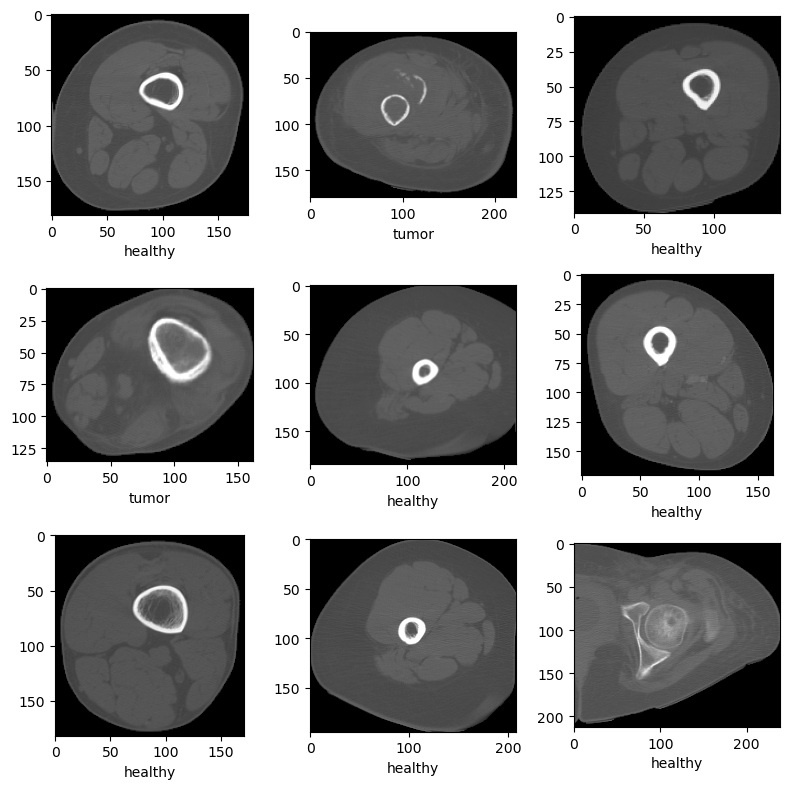

In [11]:
import matplotlib.pyplot as plt

plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(num_total, size=9)):
    with np.load(image_files_list[k]) as data:
        arr = data["arr_0"]
        if arr.ndim == 3 and arr.shape[0] == 1:  # Make sure it's 2D
            arr = arr[0]
        plt.subplot(3, 3, i + 1)
        plt.imshow(arr, cmap="gray", vmin=arr.min(), vmax=arr.max())
        plt.xlabel(class_names[image_class[k]])  # Show 'healthy' or 'tumor'
plt.tight_layout()
plt.show()



###  Image Visualization 

This code snippet generates a 3x3 grid of randomly selected medical images from a dataset and displays them using Matplotlib. First, it creates a figure with 9 subplots arranged in a 3x3 layout. It then selects 9 random image indices using np.random.randint from a total number of images (num_total). For each selected image, it loads the corresponding .npz file from image_files_list, extracts the image data (usually stored under the key "arr_0"), and ensures the image is in 2D format if it's stored with an extra channel dimension (e.g., shape (1, H, W)). Each image is then plotted in grayscale (cmap="gray") with its intensity range scaled appropriately (vmin and vmax set to the image's min and max). Below each image, the corresponding class label—either "healthy" or "tumor"—is displayed based on the image_class index and the class_names list. The layout is adjusted with plt.tight_layout() to avoid overlap, and finally, the full image grid is shown with plt.show(). This code is typically used to visually inspect and verify the dataset's contents and class distribution.

In [12]:
val_frac = 0.1
test_frac = 0.1
length = len(image_files_list)
indices = np.arange(length)
np.random.shuffle(indices)

test_split = int(test_frac * length)
val_split = int(val_frac * length) + test_split
test_indices = indices[:test_split]
val_indices = indices[test_split:val_split]
train_indices = indices[val_split:]

train_x = [image_files_list[i] for i in train_indices]
train_y = [image_class[i] for i in train_indices]
val_x = [image_files_list[i] for i in val_indices]
val_y = [image_class[i] for i in val_indices]
test_x = [image_files_list[i] for i in test_indices]
test_y = [image_class[i] for i in test_indices]

print(f"Training count: {len(train_x)}, Validation count: " f"{len(val_x)}, Test count: {len(test_x)}")

Training count: 1954, Validation count: 244, Test count: 244


### Dataset Splitting 

This code splits a dataset of medical images into training, validation, and test sets using a randomized approach. First, it sets the proportions for the validation and test sets to 10% each using val_frac and test_frac. It calculates the total number of images using len(image_files_list) and creates a list of indices representing each image. The indices are shuffled randomly with np.random.shuffle to ensure a random split. It then determines the boundaries for the test and validation sets by computing the appropriate indices: the first 10% of shuffled indices go to the test set, the next 10% to the validation set, and the remaining 80% to the training set. The code then creates separate lists of image file paths (train_x, val_x, test_x) and their corresponding class labels (train_y, val_y, test_y) using list comprehensions. Finally, it prints the number of images in each subset to confirm the split. This random shuffling and splitting process ensures that the training, validation, and test sets are mutually exclusive and representative of the overall dataset.

In [13]:
from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, ScaleIntensity, Resize,
    RandRotate, RandFlip, RandZoom
)
import numpy as np  # needed for np.pi

# Training transforms with augmentation
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity(),
    Resize((128, 128)),  
    RandRotate(range_x=np.pi / 12, prob=0.5, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
])

# Validation transforms (no randomness)
val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity(),
    Resize((128, 128)), 
])



In [14]:
class MedNISTDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels, transforms=None):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        label = self.labels[index]
        if self.transforms:
            image = self.transforms(image)
        return image, label

# Assuming you already defined train_transforms and val_transforms above
train_ds = MedNISTDataset(train_x, train_y, transforms=train_transforms)
train_loader = DataLoader(train_ds, batch_size=300, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(val_x, val_y, transforms=val_transforms)
val_loader = DataLoader(val_ds, batch_size=300, num_workers=0)

test_ds = MedNISTDataset(test_x, test_y, transforms=val_transforms)
test_loader = DataLoader(test_ds, batch_size=300, num_workers=0)




Learning Rate: controls how much the optimizer adjusts the model’s weights in response to 
the calculated gradients (errors) during training.
A high lr → Larger weight updates → Faster convergence but risk of overshooting optimal values.
A low lr → Smaller weight updates → Slower but more stable training.
Typical Values:
Adam: 1e-5 to 1e-3 (your 5e-4 is moderate).
Rule of thumb: Start with 3e-4 for Adam and adjust based on loss trends.


Weight Decay: penalizes large weights by adding a small fraction of the weight values to the loss function. 
This prevents overfitting by discouraging the model from relying too heavily on any single feature.
Typical Values:
Adam: 1e-5 to 1e-3 (start with 1e-5 and increase if overfitting).
AdamW (improved version): 1e-4 to 1e-2.



In [15]:

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=num_class).to(device)
loss_function = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.0, 5.0]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=2e-2)
max_epochs = 10
val_interval = 1
auc_metric = ROCAUCMetric()

In [16]:

from monai.data import decollate_batch
from monai.transforms import AsDiscrete


best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()
y_trans = AsDiscrete(to_onehot=2)      
y_pred_trans = AsDiscrete(threshold=0.5)
root_dir = "/home/ashah/data-2025-04-21-not-processed" 
os.makedirs(root_dir, exist_ok=True)


for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
        epoch_len = len(train_ds) // train_loader.batch_size
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            y_pred = torch.tensor([], dtype=torch.float32, device=device)
            y = torch.tensor([], dtype=torch.long, device=device)
            for val_data in val_loader:
                val_images, val_labels = (
                    val_data[0].to(device),
                    val_data[1].to(device),
                )
                y_pred = torch.cat([y_pred, model(val_images)], dim=0)
                y = torch.cat([y, val_labels], dim=0)
            y_onehot = [y_trans(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [y_pred_trans(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)
            acc_value = torch.eq(y_pred.argmax(dim=1), y)
            acc_metric = acc_value.sum().item() / len(acc_value)
            if result > best_metric:
                best_metric = result
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current accuracy: {acc_metric:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
            writer.add_scalar("val_accuracy", acc_metric, epoch + 1)

print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")
writer.close()

----------
epoch 1/10
1/6, train_loss: 0.6576
2/6, train_loss: 0.5491
3/6, train_loss: 0.4801
4/6, train_loss: 0.4178
5/6, train_loss: 0.3931
6/6, train_loss: 0.3833
7/6, train_loss: 0.4286
epoch 1 average loss: 0.4728
saved new best metric model
current epoch: 1 current AUC: 0.5000 current accuracy: 0.5451 best AUC: 0.5000 at epoch: 1
----------
epoch 2/10
1/6, train_loss: 0.4071
2/6, train_loss: 0.3555
3/6, train_loss: 0.3349
4/6, train_loss: 0.3731
5/6, train_loss: 0.3199
6/6, train_loss: 0.2897
7/6, train_loss: 0.3483
epoch 2 average loss: 0.3469
current epoch: 2 current AUC: 0.5000 current accuracy: 0.5451 best AUC: 0.5000 at epoch: 1
----------
epoch 3/10
1/6, train_loss: 0.3039
2/6, train_loss: 0.3377
3/6, train_loss: 0.2898
4/6, train_loss: 0.2831
5/6, train_loss: 0.2804
6/6, train_loss: 0.2641
7/6, train_loss: 0.2454
epoch 3 average loss: 0.2863
current epoch: 3 current AUC: 0.5000 current accuracy: 0.5451 best AUC: 0.5000 at epoch: 1
----------
epoch 4/10
1/6, train_loss: 0.2

### Model Training and Evaluation Loop

This code defines the full training and validation loop for a binary classification model using MONAI and PyTorch. It begins by setting up key variables, including metrics tracking, a TensorBoard writer (SummaryWriter()), and MONAI’s AsDiscrete transforms for converting model outputs and labels into binary format y_trans for o encoding labels and y_pred_trans for thresholding predictions.

During training, the model enters a loop over max_epochs. In each epoch, the model is set to training mode with model.train(), and batches from the train_loader are processed one at a time. For each batch, input images and their corresponding labels are moved to the target device (GPU). The model generates predictions, the loss is computed, and gradients are updated through backpropagation. The loss per step is accumulated and averaged over the entire epoch. The average loss and individual step losses are logged using TensorBoard.

Every few epochs, based on the val_interval, the model switches to evaluation mode using model.eval() and disables gradient tracking with torch.no_grad(). The validation data is processed similarly, and predictions and labels are collected. The labels are converted to one-hot format, and predictions are thresholded. An AUC metric is calculated using MONAI's auc_metric, and classification accuracy is manually computed. If the AUC score is higher than any previously recorded, the model is saved as the new best performer.

Finally, after all epochs are completed, the script prints the best AUC score and its corresponding epoch, and the TensorBoard writer is closed. This process ensures that model performance is closely tracked and that the best-performing model is preserved for future use.

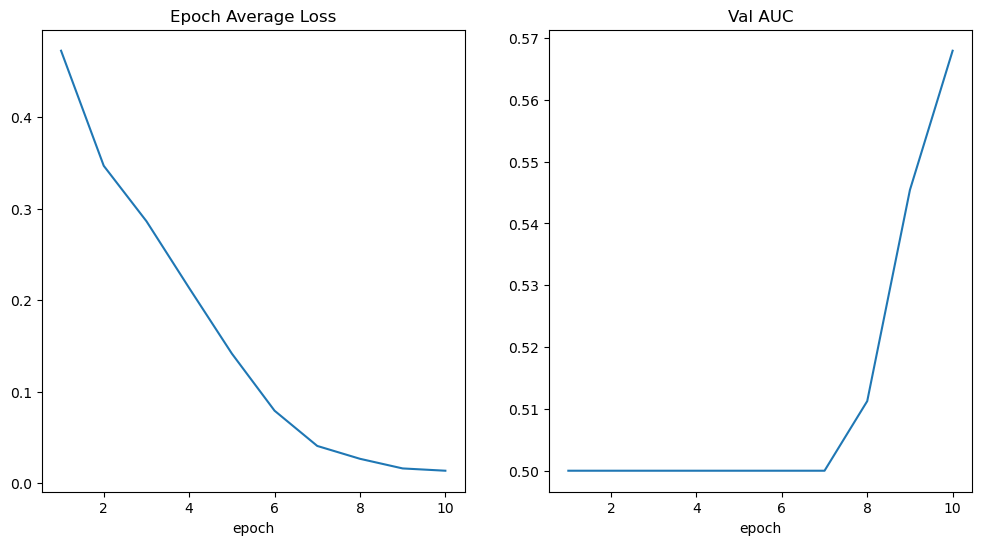

In [17]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val AUC")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

In [18]:
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = (
            test_data[0].to(device),
            test_data[1].to(device),
        )
        pred = model(test_images).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

In [19]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

     healthy     1.0000    0.1544    0.2675       136
       tumor     0.4843    1.0000    0.6526       108

    accuracy                         0.5287       244
   macro avg     0.7422    0.5772    0.4600       244
weighted avg     0.7717    0.5287    0.4379       244



### Classification Report Results

This classification report summarizes the performance of a binary classification model that distinguishes between "healthy" and "tumor" cases across 244 test samples. The model achieved an overall accuracy of 52.87%, which means it correctly classified just over half of the samples. However, a deeper look reveals an imbalanced performance between the two classes.

For the "tumor" class, the model performed quite well: it achieved a recall of 1.0000, meaning it correctly identified all tumor cases, and a precision of 0.4843, indicating that about 48% of its tumor predictions were actually correct. This results in an F1-score of 0.6526, reflecting a solid balance between precision and recall.

In contrast, the model's performance on the "healthy" class was poor. It had a recall of only 0.1544, meaning it identified just 15% of the actual healthy cases correctly. Although its precision was perfect (1.0000) every time it predicted "healthy," it was correct this happened very rarely. As a result, the F1-score for healthy is low at 0.2675, showing a significant shortfall in recognizing healthy cases.

The macro average F1-score (0.4600) and weighted average F1-score (0.4379) further indicate that, despite good tumor detection, the model is imbalanced and biased toward predicting tumors. This likely stems from the model prioritizing sensitivity (catching all tumors) at the cost of specificity (mislabeling healthy patients as tumors), which can be critical depending on the medical context.

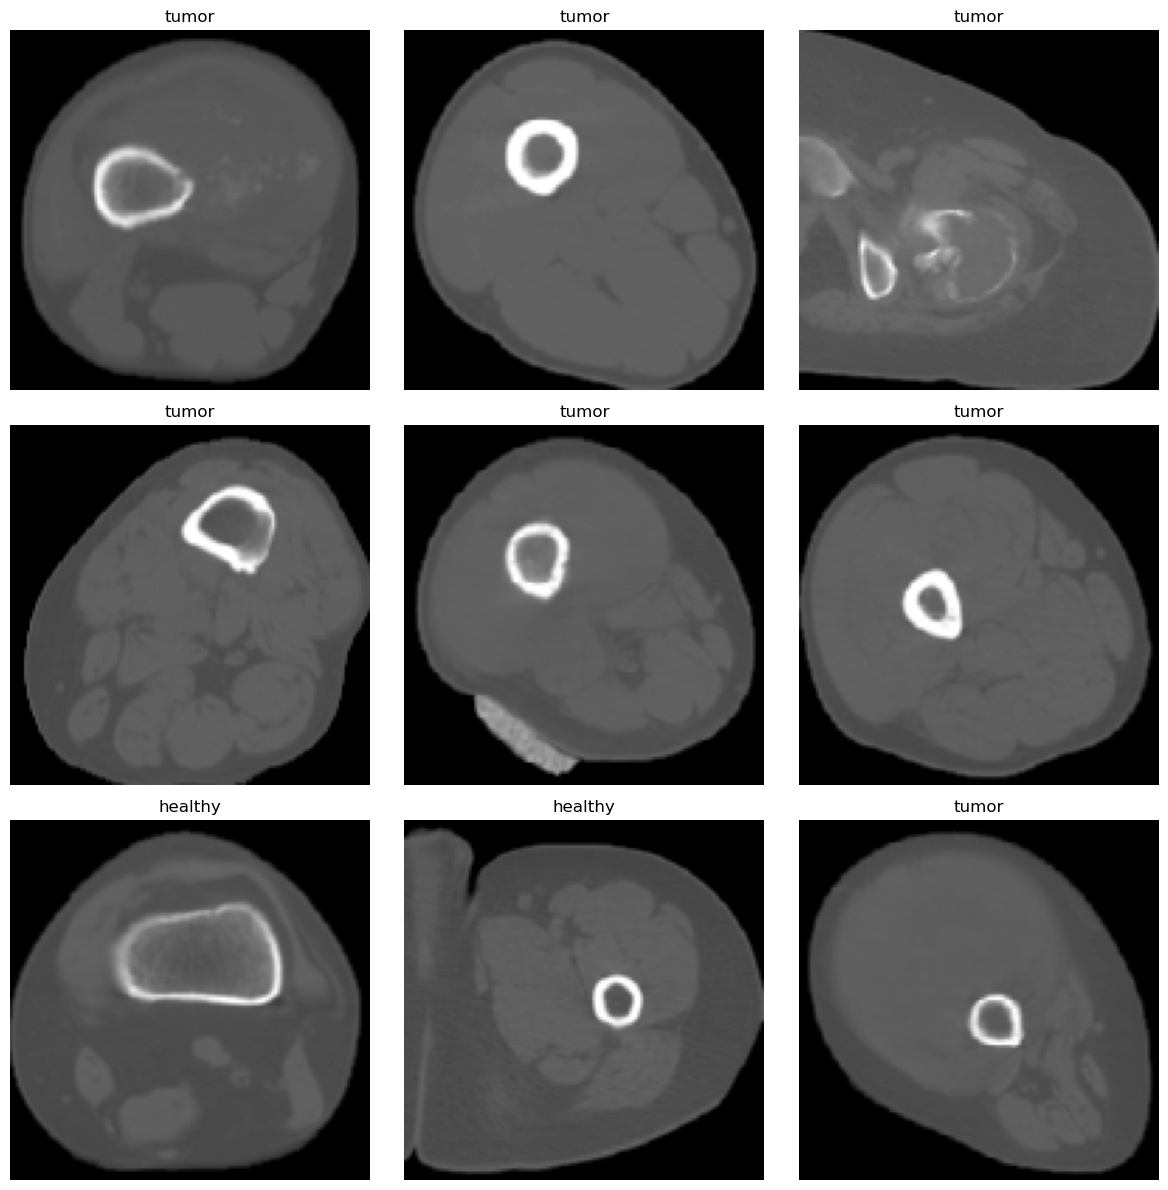

In [20]:
label_map = {0: "healthy", 1: "tumor"}

import matplotlib.pyplot as plt
import numpy as np
import math

batch = next(iter(train_loader))
images, labels = batch

num_to_show = 9
num_to_show = min(num_to_show, len(images))

cols = math.ceil(math.sqrt(num_to_show))
rows = math.ceil(num_to_show / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten() if num_to_show > 1 else [axes]

for i in range(num_to_show):
    img = images[i].cpu().numpy()
    if img.shape[0] == 1:
        img = img[0]
        axes[i].imshow(img, cmap='gray')
    else:
        img = np.transpose(img, (1, 2, 0))
        axes[i].imshow(img)

    axes[i].set_title(f"{label_map.get(labels[i].item(), 'unknown')}")
    axes[i].axis('off')

for j in range(num_to_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
